# Minimal cellAdmix CosMx Example

## Overview

This notebook illustrates the basic cellAdmix workflow on a CosMx NSCLC
example. The goal is to identify molecular factors that describe local
transcript neighborhoods, annotate those factors with likely source cell
types, detect source-target admixture patterns, and produce corrected
cell-by-gene counts after removing molecules assigned to likely
admixture.

At a high level, the user-facing workflow is:

In [ ]:
ds <- cellAdmix(molecules_file, output_dir = output_dir, annotation = cell_annotation)
fit <- ds$fit()
score <- fit$score_bridge()
rules <- score$rules()
correction <- score$correct(rules = rules)
corrected_counts <- correction$counts()

The constructor records where the input files and output cache live,
validates the configuration, and stores lightweight cell-level metadata.
It does not load the full molecule table into R memory. The
computational work starts with `fit()`, which builds neighborhood
composition vectors, fits NMF factors, and assigns molecules to factors.
Scoring then interprets these factors as possible source-target
admixture patterns, and correction removes rule-supported admixture
molecules to produce corrected counts.

## Data Preparation

cellAdmix itself works with generic molecule tables and optional cell
metadata. The raw inputs for this example are more dataset-specific: a
Giotto object with cell metadata, a CosMx transcript CSV, and a small
curated annotation table. We keep that conversion outside the main
notebook so that the vignette focuses on the standard cellAdmix API
rather than on one dataset’s loading details.

To regenerate the prepared files, download the raw example files from
`http://pklab.org/peterk/cellAdmix/examples/cosmx_nsclc/` and place them
in a local folder named `data/` next to this notebook:

-   `data/SMI_Giotto_Object.RData`
-   `data/Lung5_Rep1_tx_file.csv.gz`
-   `data/annotation_adj.csv.gz`

Then run the conversion script from the `examples/cosmx_nsclc_giotto`
directory:

`Rscript prepare_cosmx_tabular.R --input data --output prepared`

The script writes gzip-compressed tabular files under `prepared/`:

-   `prepared/molecules_all.csv.gz`: one molecule per row, with spatial
    coordinates, gene identity, and assigned cell ID.
-   `prepared/cell_metadata_all.csv.gz`: one row per cell, with cell
    type labels, spatial centroids, and a few diagnostic columns used
    later for illustration.

The conversion does not require the Giotto package to be installed. It
loads the saved Giotto object and reads only the object attributes
containing cell-level metadata and raw spatial cell centroids. The
curated annotation table supplies the cell-type labels and diagnostic
region labels. The transcript CSV supplies the molecule coordinates,
genes, FOV IDs, and raw cell IDs; the script filters out unassigned
cells and negative probes, converts CosMx pixel coordinates to microns,
and writes the standard tabular molecule file consumed by cellAdmix.

The rest of the notebook starts from those prepared files. This is the
same input pattern that can be used for other tabular molecule datasets.

## Prepared Inputs

We first point the notebook at the prepared molecule and cell-metadata
files, then load the small cell metadata table into R for annotation
summaries and plotting.

In [ ]:
molecules_file <- file.path("prepared", "molecules_all.csv.gz")
cell_metadata_file <- file.path("prepared", "cell_metadata_all.csv.gz")

cell_meta <- read.csv(cell_metadata_file, stringsAsFactors = FALSE)
rownames(cell_meta) <- cell_meta$cell

table(cell_meta$cell_type_coarse)


 endothelial   epithelial   fibroblast immune other   macrophage    malignant 
        7613         4098        13151        47131         7409        18600 

The spatial plot below is not part of the core algorithm. It is a quick
check that the prepared annotations and cell coordinates are aligned
with the tissue layout.

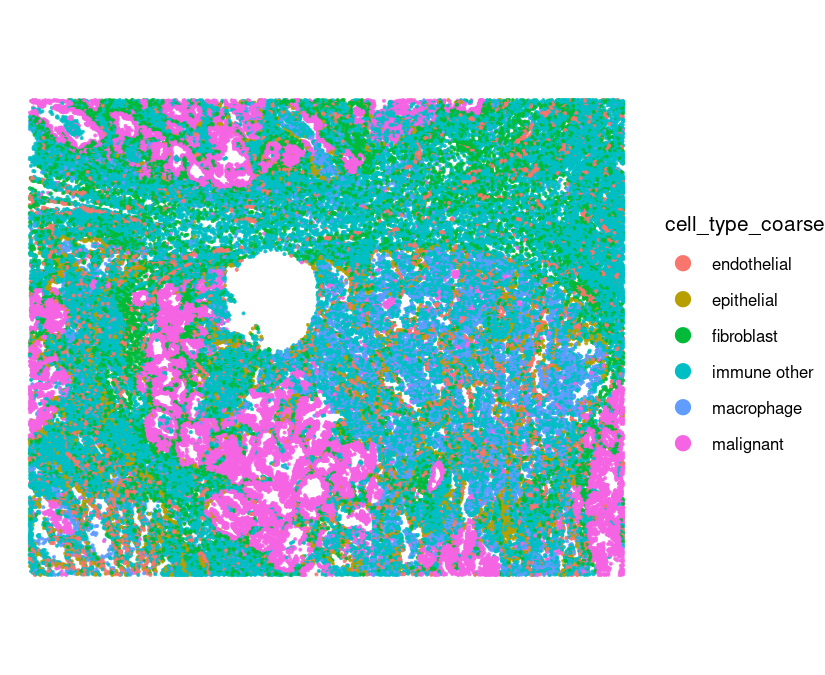

In [ ]:
celladmix_plot_spatial(cell_meta, color_by = "cell_type_coarse")

## cellAdmix Fit

The `cellAdmix()` constructor records the input files and creates an
output directory for reusable caches and analysis results. The coarse
cell annotation is passed as a named vector, where names are cell IDs
and values are cell-type labels. The molecule CSV is not loaded into R
memory at construction time; it is streamed into a cellAdmix store as
needed by downstream steps.

In [ ]:
output_dir <- "out"
cell_annotation <- setNames(cell_meta$cell_type_coarse, cell_meta$cell)

ds <- cellAdmix(molecules_file, output_dir = output_dir, annotation = cell_annotation)

ds

cellAdmix dataset
  format: tabular 
  output cache: configured
  threads: 10 
  molecules: molecules_all.csv.gz 
  annotation:manual (98002 cells, 6 labels)

The fit call constructs neighborhood composition vectors around
molecules, factorizes them, and assigns each molecule to a factor. By
default, the rank is chosen from the number of annotation labels, NMF
uses inverse-square-root weighted KL, molecule scoring uses gene
loadings, and the number of NMF starts matches the dataset thread
setting.

In [ ]:
fit <- ds$fit()
score_pairs_width <- 9.6
score_pairs_height <- max(6, ceiling(fit$rank / 2) * 4.9)

fit

cellAdmix fit
  run: fit_manual_rank8_invsqrt_kl 
  annotation: manual 
  rank: 8 
  NMF: invsqrt_kl 
  molecule scoring: gene_loadings 
  cells: 98002 
  transcripts: 30245074 

Top gene loadings help interpret each factor. These are the genes most
strongly associated with each fitted factor, so they are the first place
to look for native cell-type signatures or possible admixture
signatures.

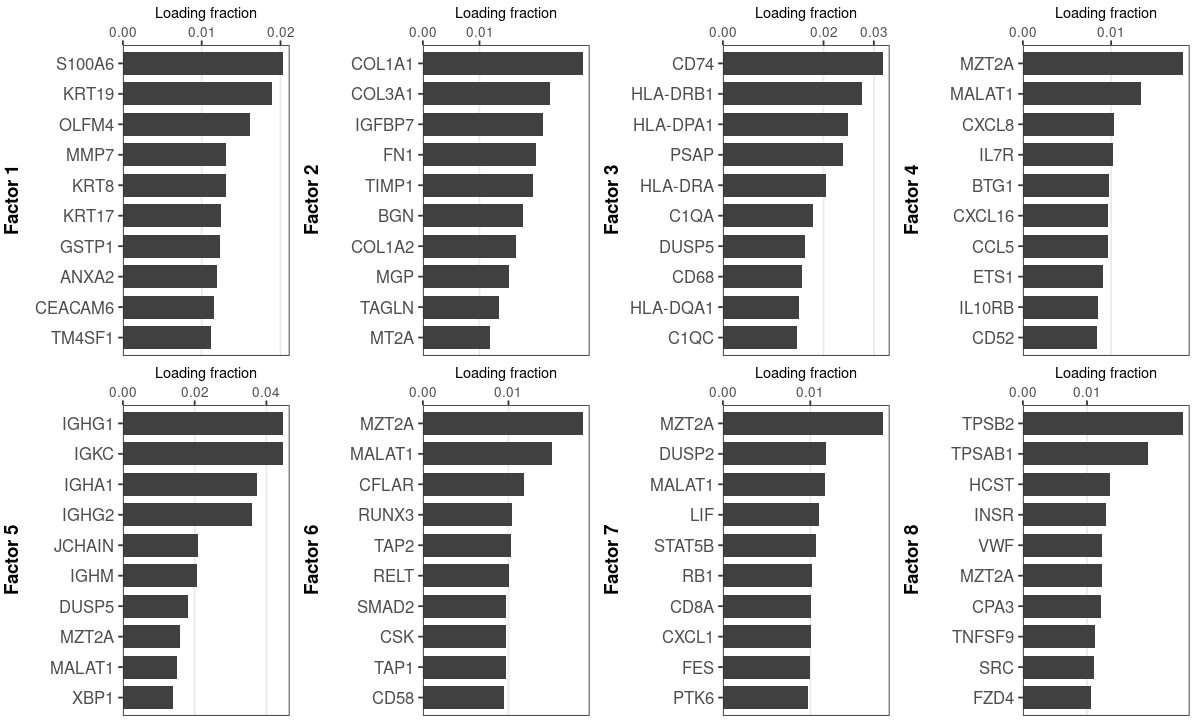

In [ ]:
fit$plot_loadings()

The stability plot summarizes how reproducible factors were across the
random NMF starts. Stable, high-importance factors are easier to
interpret; unstable or low-importance factors should be treated more
cautiously.

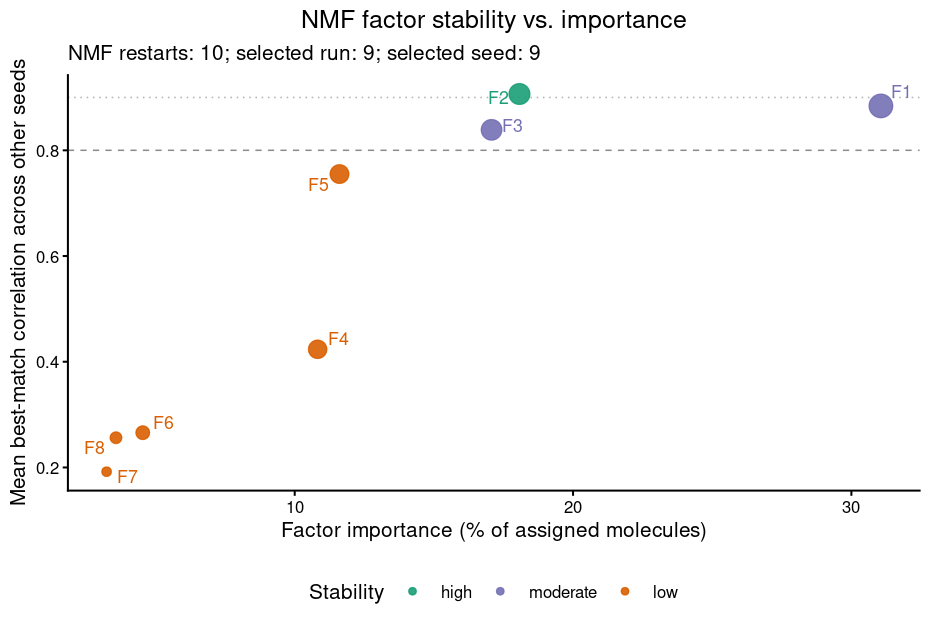

In [ ]:
fit$plot_stability()

As another quick sanity check, we can show the dominant factor
assignment for each cell in tissue coordinates.

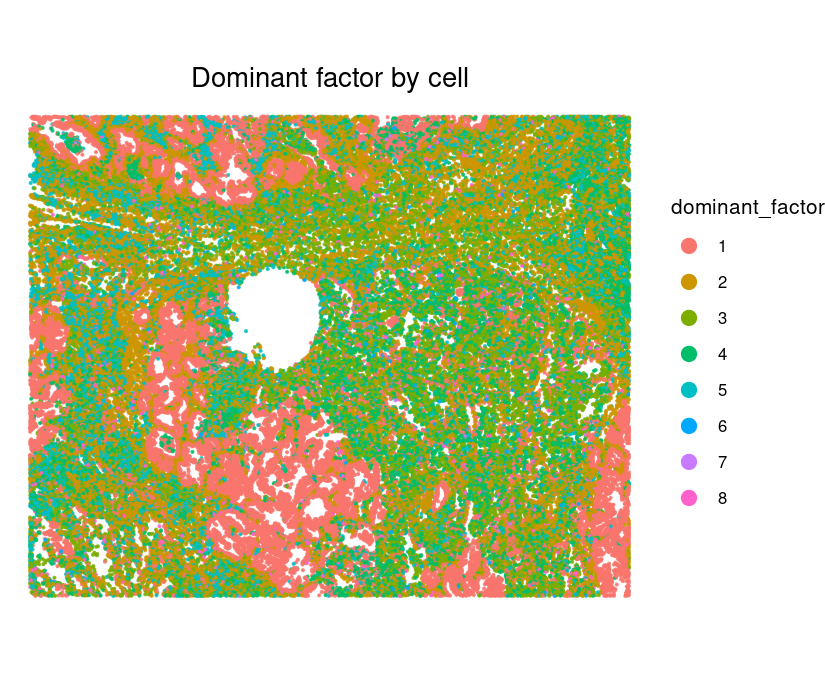

In [ ]:
cell_factors <- fit$cell_factors()
celladmix_plot_spatial(cell_factors, color_by = "dominant_factor") +
  ggplot2::ggtitle("Dominant factor by cell")

## Bridge Scoring

Bridge scoring asks whether molecules assigned to a factor in a target
cell type are spatially connected to plausible source cell types. This
converts the unlabeled factors into candidate source-target correction
rules.

In [ ]:
bridge <- fit$score_bridge()

The score object is then converted into correction rules. Each row
indicates a factor, its inferred source cell type, and a target cell
type where that factor is called as potential admixture. We only print
the first few columns and rows to avoid dumping a large table.

In [ ]:
rules <- bridge$rules()
head(rules[, c("factor", "source_cell_type", "target_cell_type", "p_value")])

  factor source_cell_type target_cell_type      p_value
1      1       epithelial      endothelial 3.588959e-06
2      1       epithelial       fibroblast 8.044307e-09
3      1       epithelial     immune other 4.057664e-05
4      1       epithelial       macrophage 5.031203e-03
5      1       epithelial        malignant 8.641756e-08
6      2       fibroblast      endothelial 1.275160e-05

The heatmap shows which source cell types are implicated for each factor
and target cell type. It is a compact way to check whether the factor
annotations make biological sense before applying correction.

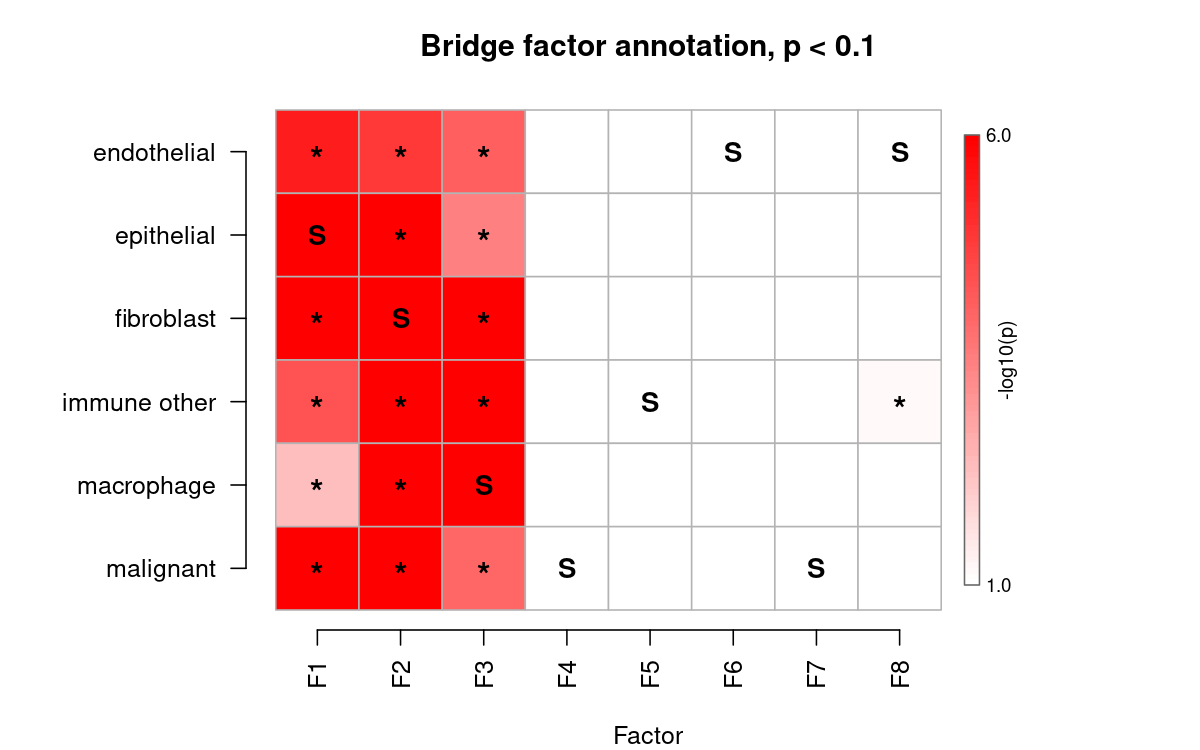

In [ ]:
bridge$plot_heatmap()

The pair plots show the same bridge evidence one factor at a time. They
make it easier to inspect whether inferred source cell types and
significant target cell types form a coherent source-target pattern.

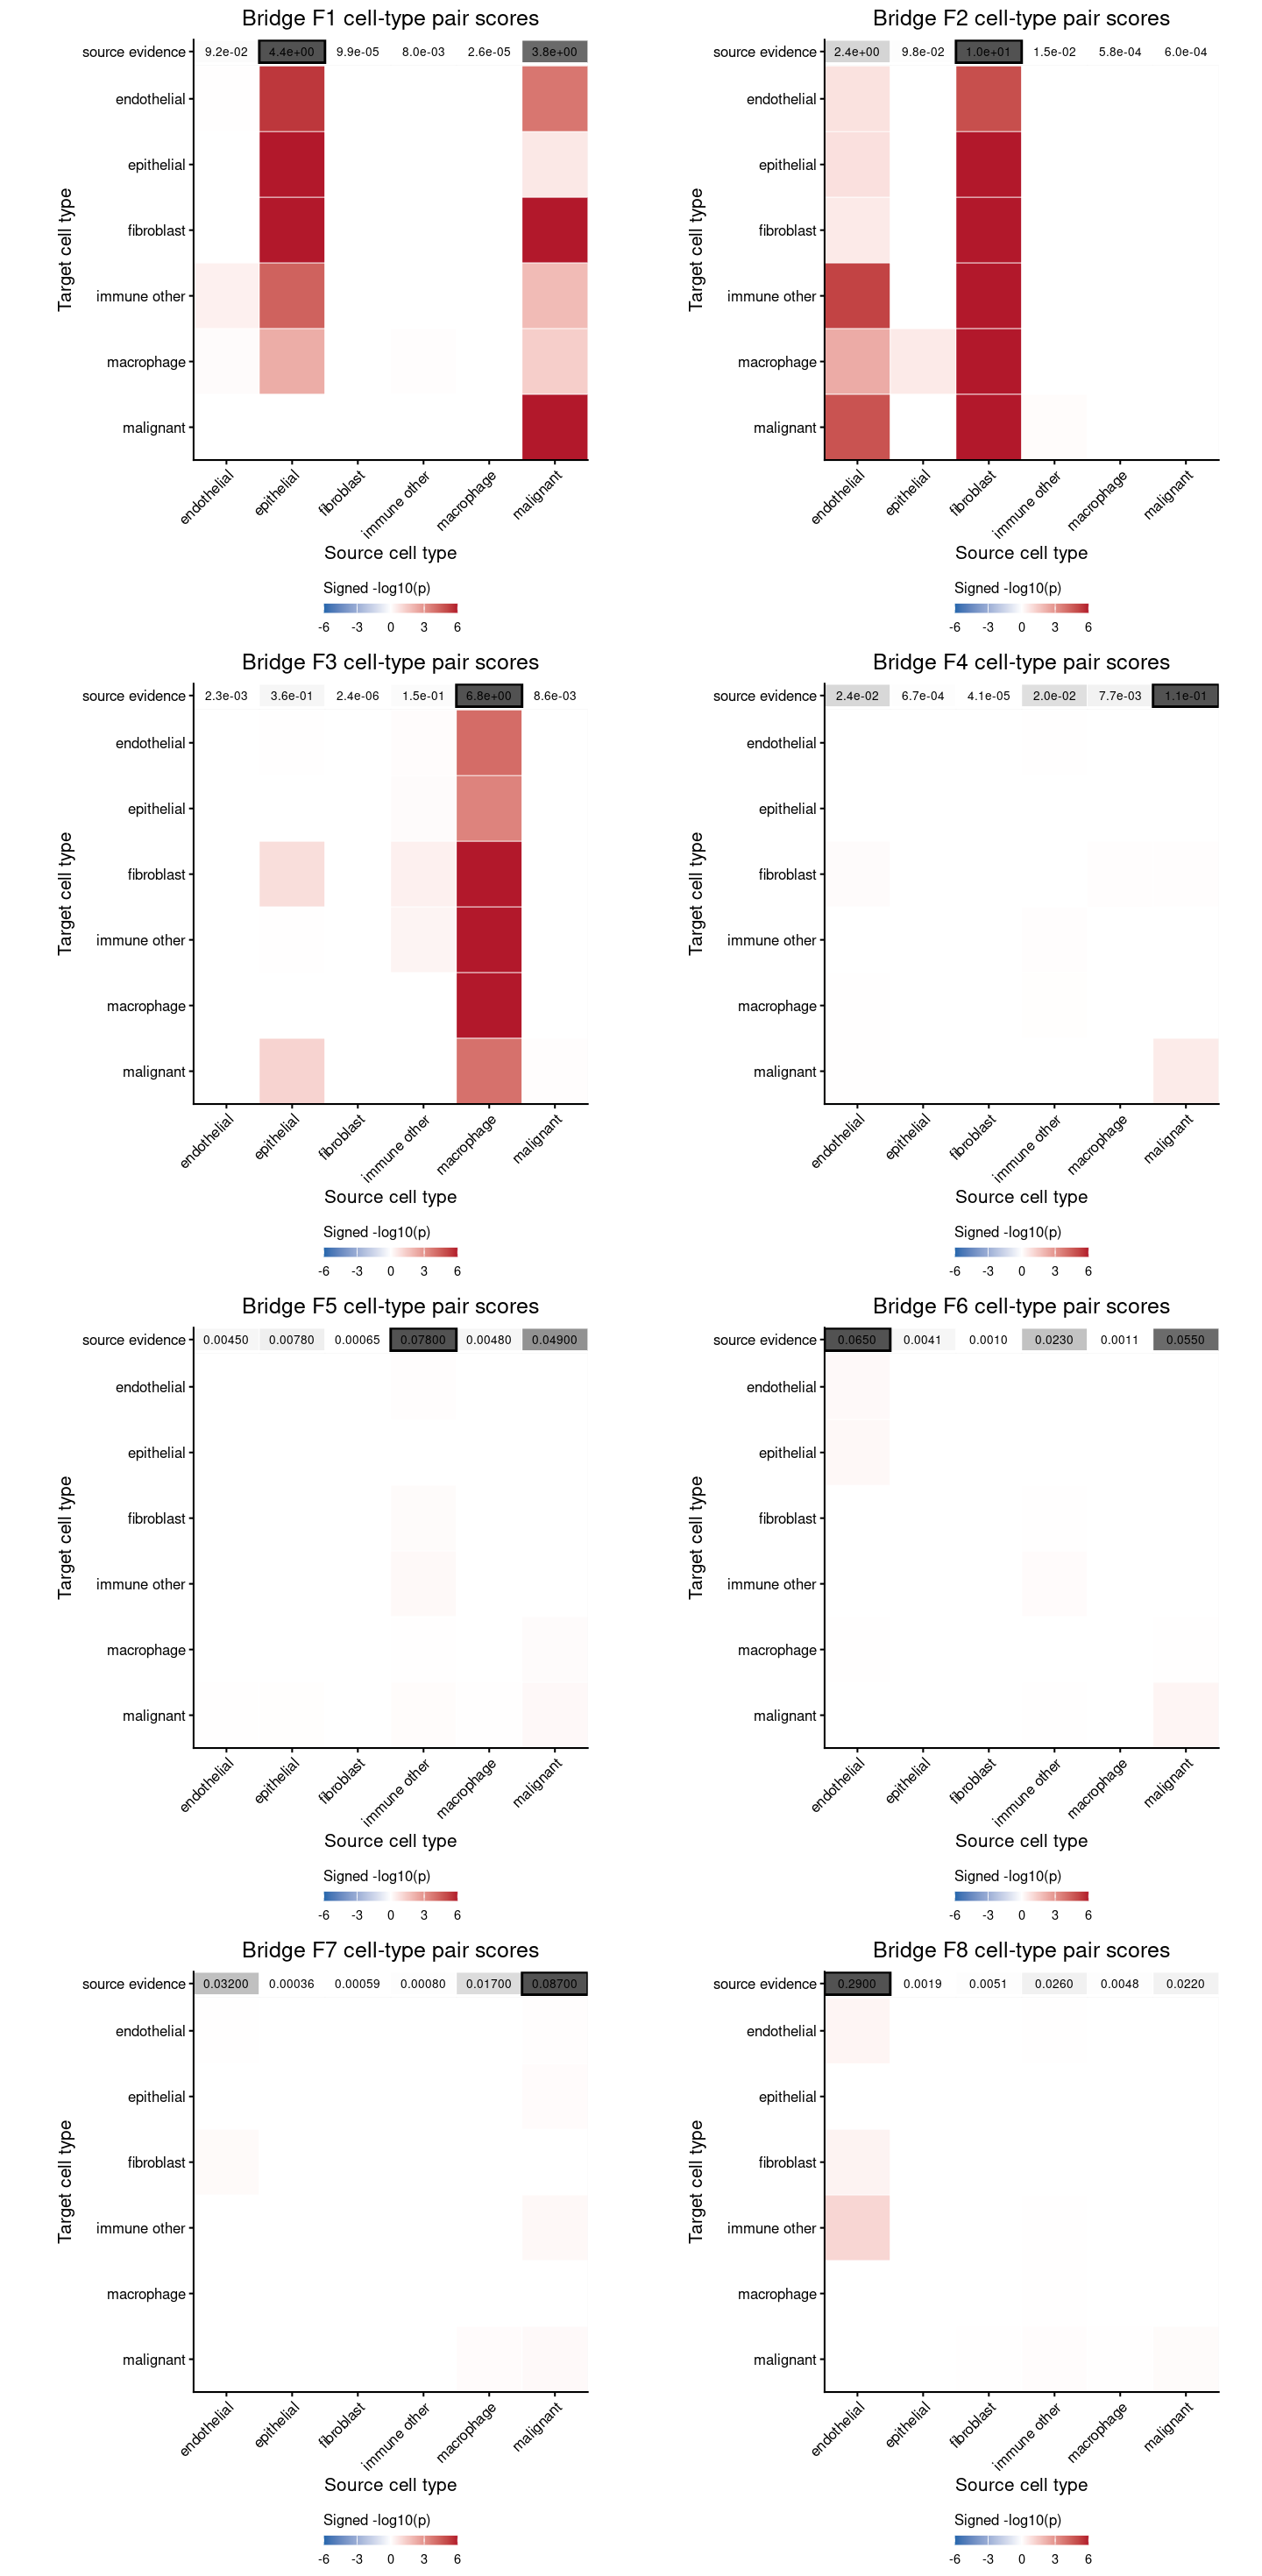

In [ ]:
bridge$plot_pairs()

## Cleanup

Cleanup removes molecules matching the bridge-supported
source-target-factor rules. The operation writes a corrected run into
the output directory and keeps the original fit unchanged.

In [ ]:
correction <- bridge$correct(rules = rules)

correction$summary()

     cell_type n_cells n_modified_cells fraction_cells_modified
1          all   98002            97767               0.9976021
2  endothelial    7613             7613               1.0000000
3   epithelial    4098             4091               0.9982918
4   fibroblast   13151            13044               0.9918637
5 immune other   47131            47110               0.9995544
6   macrophage    7409             7310               0.9866379
7    malignant   18600            18599               0.9999462
  molecules_before molecules_after molecules_removed fraction_molecules_removed
1         30245074        14622095          15622979                 0.51654623
2          2299672          807261           1492411                 0.64896690
3          1532030         1131714            400316                 0.26129776
4          3932478         3460455            472023                 0.12003195
5         10859357         5736429           5122928                 0.47175243
6       

The next plot summarizes how many molecules were removed in modified
cells. Large removals should be inspected carefully, while very small
removals may have little impact on downstream summaries.

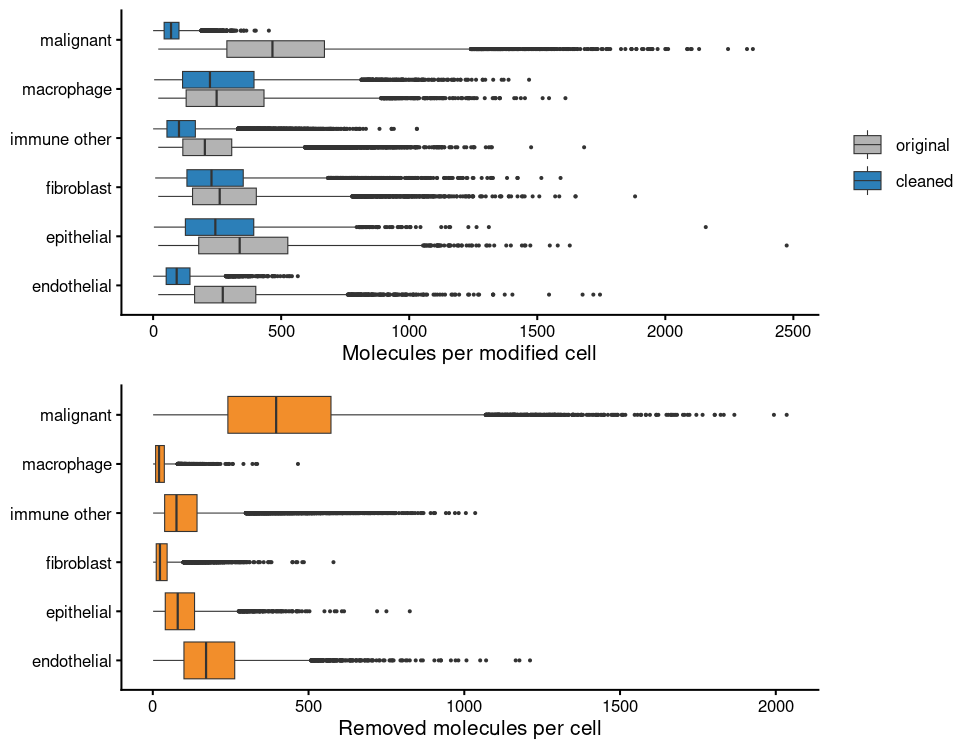

In [ ]:
correction$plot_removed_molecules()

## Correction Diagnostics

For this example, the diagnostic question is whether malignant
epithelial marker signal in fibroblast cells is reduced after cleanup,
while native fibroblast marker signal is preserved. These plots are not
required for cellAdmix itself; they are an interpretable downstream
check for this dataset.

In [ ]:
malignant_marker_genes <- c(
  "KRT19", "KRT8", "KRT18", "TACSTD2", "CEACAM6", "CDH1", "EPCAM",
  "CLDN4", "SFN", "PHLDA2", "DDR1", "AGR2", "KRT6A", "KRT17",
  "CD24", "KRT5", "AQP3", "SLC2A1", "KRT7", "COL17A1", "FASN",
  "KRT15", "ITGA2", "ERBB3", "S100A2", "SPINK1", "ITGB4", "PIGR",
  "SOX2", "ITGA3", "CYSTM1", "NTRK2", "MAPK13", "CCND1", "HDAC1", "EGFR"
)
malignant_label_genes <- c("KRT19", "KRT8", "KRT17", "CEACAM6")
fibroblast_marker_genes <- c("MYL9", "CXCL12", "PDGFRB", "RARRES2")

counts <- fit$counts()
fib_cells <- rownames(cell_meta)[
  cell_meta$celltype == "fibroblast" & !is.na(cell_meta$regions_compare)
]
fib_cells <- intersect(fib_cells, colnames(counts))
regions_compare <- setNames(cell_meta[fib_cells, "regions_compare"], fib_cells)
de_out_orig <- celladmix_de(counts[, fib_cells, drop = FALSE], regions_compare,
  contrast = c("tumor", "stroma"))
impact <- celladmix_correction_impact(correction, counts, fib_cells,
  regions_compare, contrast = c("tumor", "stroma"))

data.frame(fibroblast_cells = length(fib_cells),
  regions = paste(sort(unique(na.omit(regions_compare))), collapse = ", "))

  fibroblast_cells       regions
1             7031 stroma, tumor

The uncorrected volcano plot compares fibroblast cells in
tumor-associated regions with fibroblast cells in stromal regions.
Malignant markers enriched in the tumor-associated fibroblasts are the
signal we expect cleanup to reduce.

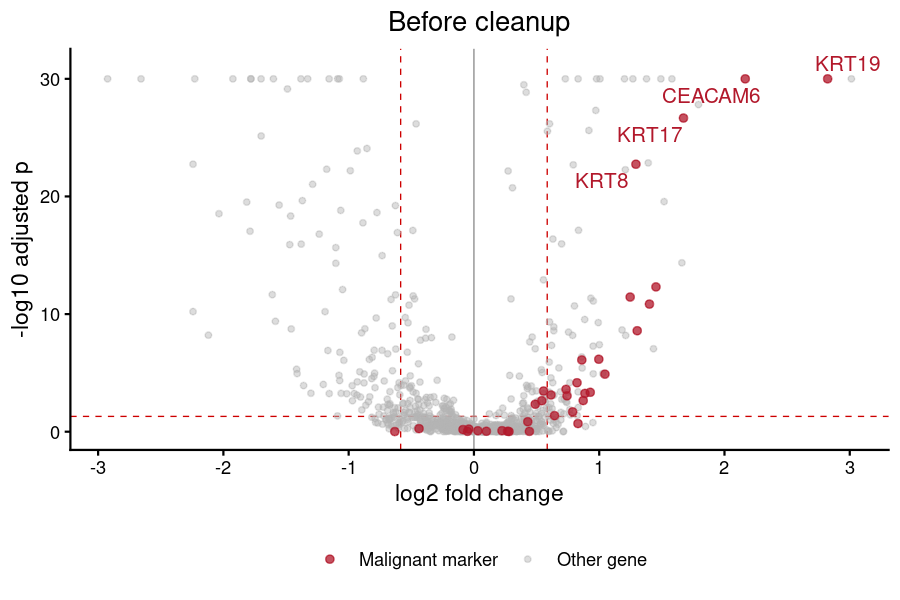

In [ ]:
celladmix_plot_volcano(de_out_orig, markers = malignant_marker_genes,
  label = malignant_label_genes, marker_label = "Malignant marker",
  title = "Before cleanup")

The marker barplots compare mean normalized expression before and after
cleanup within fibroblast cells. The desired pattern is preservation of
native fibroblast markers and reduction of malignant marker signal.

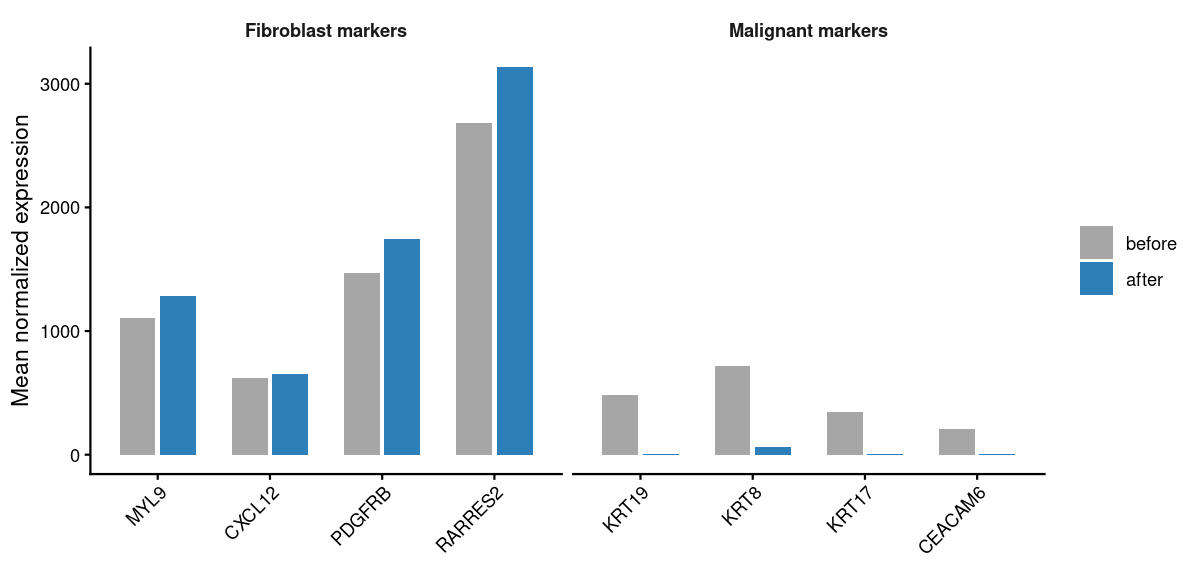

In [ ]:
celladmix_plot_marker_expression(counts, impact$counts, fib_cells,
  markers = list("Fibroblast markers" = fibroblast_marker_genes,
    "Malignant markers" = malignant_label_genes))

The cleaned volcano plot repeats the same fibroblast comparison after
molecule removal. A successful correction should shift suspicious
malignant markers toward weaker significance and smaller tumor-region
enrichment.

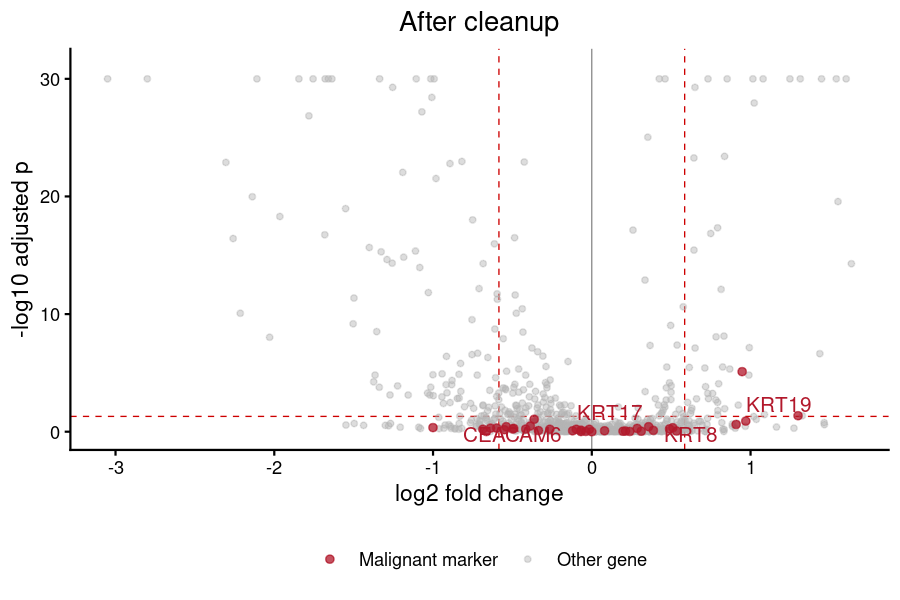

In [ ]:
celladmix_plot_volcano(impact$de, markers = malignant_marker_genes,
  label = malignant_label_genes, marker_label = "Malignant marker",
  title = "After cleanup")

The final scatter plot directly compares signed adjusted-p-value
significance before and after cleanup. Positive values indicate
tumor-region enrichment within fibroblasts, negative values indicate
stromal-region enrichment, and points below the diagonal became less
significant after cleanup. Highlighted malignant markers moving toward
zero are consistent with reduced malignant admixture signal.

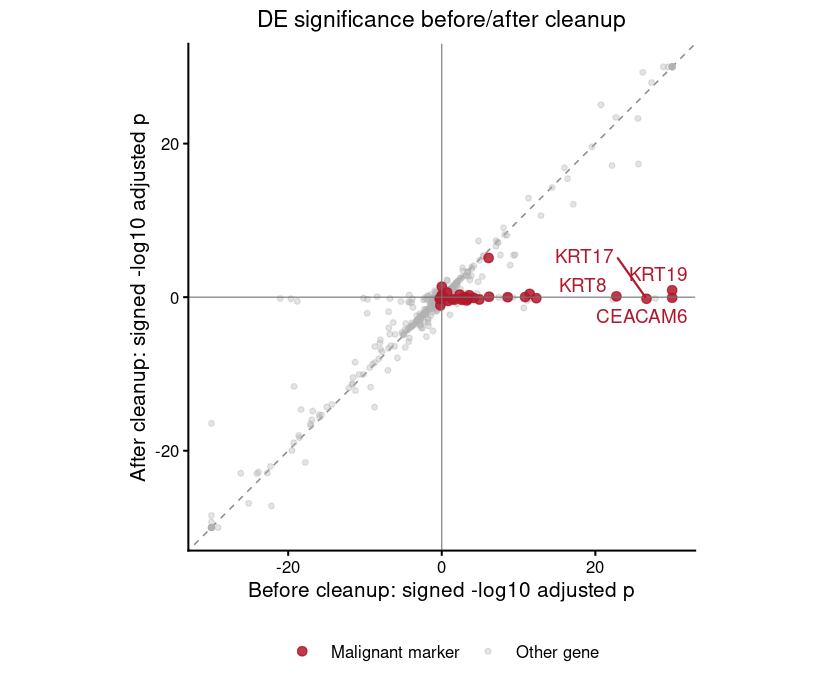

In [ ]:
celladmix_plot_de_shift(de_out_orig, impact$de,
  markers = malignant_marker_genes, label = malignant_label_genes,
  marker_label = "Malignant marker")

The expected result is not that every malignant marker disappears.
Instead, the correction should remove the molecule subset assigned to
bridge-supported admixture factors, reduce the strongest suspicious
marker signal in target cells, and leave native fibroblast markers
largely intact.